# Implementación de un ARIMA(p,d,q)(P,D,Q) paso a paso

Pronóstico del consúmo eléctrico en California

In [37]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


# Modelos ARIMA con stasforecast y statsmodels
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoETS
from pmdarima.arima import nsdiffs


In [3]:
df = pd.read_csv('datos/demanda_electricidad_california.csv')
df

,unique_id,ds,y
0,california,2025-04-27 17:00:00,21997.0
1,california,2025-04-27 18:00:00,21418.0
2,california,2025-04-27 19:00:00,21343.0
3,california,2025-04-27 20:00:00,21908.0
4,california,2025-04-27 21:00:00,22124.0
...,...,...,...
1995,california,2025-07-19 20:00:00,29380.0
1996,california,2025-07-19 21:00:00,27763.0
1997,california,2025-07-19 22:00:00,26659.0
1998,california,2025-07-19 23:00:00,26438.0


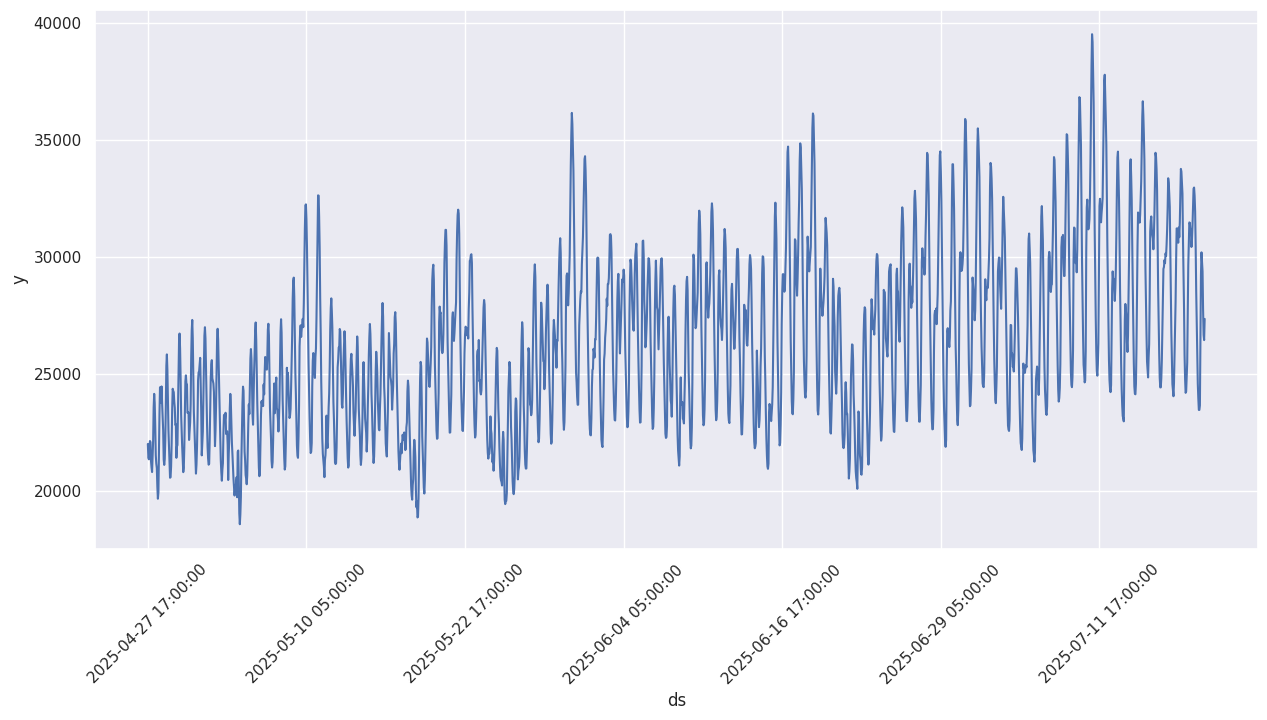

In [12]:
fig, ax =plt.subplots(1, 1, figsize = (15, 7))
sns.lineplot(df, x = 'ds', y = 'y', ax = ax)
ax.grid(True)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=8))
plt.xticks(rotation=45)
plt.show()

Se aprecia una serie de tiempo que tiene una ligera tendencia positiva, además, se nota un patrón estacional que, al tratarse de una serie de tiempo de consumo enerético, posiblemente se trata de una periodicidad de 24 horas.

### Modelo Base Suavizado Exponencial

Para hacer un comparativo ,en este caso el modelo base será un modelo de suavizado exponencial con error multiplicativo, tendencia aditiva amortiguada y estacionalidad multiplicativa.

In [21]:
def metricas_cv(cv_df, nombre_modelos):
    resultados = []
    for modelo in nombre_modelos:
        #Agrupar por cutoff y calcular métricas
        metricas_ventana = []
        for cutoff in cv_df['cutoff'].unique():
            ventana = cv_df[cv_df['cutoff'] == cutoff]
            y_true = ventana['y']
            y_pred = ventana[modelo]

            rmse = np.sqrt(np.mean(y_true - y_pred)**2)
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            mae = np.mean(np.abs(y_true - y_pred))

            metricas_ventana.append({'rmse' : rmse, 'mape' : mape, 'mae' : mae})
        
        metricas_df = pd.DataFrame(metricas_ventana)
        resultados.append({
            'Modelo'   : modelo,
            'RMSE'     : metricas_df['rmse'].mean(),
            'MAPE'     : metricas_df['mape'].mean(),
            'MAE'      : metricas_df['mae'].mean(),
            'RMSE_STD' : metricas_df['rmse'].std(),
            'MAPE_STD' : metricas_df['mape'].std(),     
            'MAE_STD'  : metricas_df['mae'].std()    
        })
    df_resultados = pd.DataFrame(resultados)
    df_resultados.index = df_resultados.index + 1
    return df_resultados

* Set de entrenamiento:[:últimas 24 horas]
* Set de prueba       : [últimas 24 horas:]     

In [14]:
df_train = df[:-24]
df_test = df[-24:]
print(df_train.tail(10))
print(df_test.head(10))

       unique_id                   ds        y
1966  california  2025-07-18 15:00:00  25477.0
1967  california  2025-07-18 16:00:00  27766.0
1968  california  2025-07-18 17:00:00  29634.0
1969  california  2025-07-18 18:00:00  30628.0
1970  california  2025-07-18 19:00:00  31468.0
1971  california  2025-07-18 20:00:00  31447.0
1972  california  2025-07-18 21:00:00  31102.0
1973  california  2025-07-18 22:00:00  31182.0
1974  california  2025-07-18 23:00:00  30418.0
1975  california  2025-07-19 00:00:00  30741.0
       unique_id                   ds        y
1976  california  2025-07-19 01:00:00  31331.0
1977  california  2025-07-19 02:00:00  32114.0
1978  california  2025-07-19 03:00:00  32908.0
1979  california  2025-07-19 04:00:00  32959.0
1980  california  2025-07-19 05:00:00  32605.0
1981  california  2025-07-19 06:00:00  31926.0
1982  california  2025-07-19 07:00:00  30425.0
1983  california  2025-07-19 08:00:00  28522.0
1984  california  2025-07-19 09:00:00  27161.0
1985  califor

## Suavizado exponencial

In [22]:
# Instancia del modelo base
modelo_base = [AutoETS(season_length=24, model='MAM', damped=True, alias='modelo_base')]
sf = StatsForecast(
    models=modelo_base,
    freq='h',  # horas
    n_jobs=-1
)

# Validación cruzada: 10 ventanas de tamaño fijo
cv_df = sf.cross_validation(
    df=df_train,
    h=24, # Horizonte del pronóstico
    step_size=24, # Entre ventanas consecutivas saltar 24 horas
    n_windows=10, # 10 ventanas
)

# Desempeño
metricas_modelo_base = metricas_cv(cv_df, ['modelo_base'])
metricas_modelo_base

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
1,modelo_base,1179.002313,4.504568,1363.531364,596.835289,1.863908,487.441073


## SARIMA

In [51]:
def prueba_diferenciacion(serie, d, D, m):
    serie = serie.dropna()

    if d != 0:
        for _ in range(d):
            serie = serie.diff()
    
    if D != 0:
        for _ in range(D):
            serie = serie.diff(m)
    
    resultado_estacionario = adfuller(serie.dropna())
    pvaladfuller = resultado_estacionario[1]

    print('>Prueba Estacionariedad con Dickey-Fuller')
    if pvaladfuller < 0.05:
        print('Rechazar H0: Serie Estacionaria')
        print(f'pval: {pvaladfuller:.4f} < 0.05')
        print('Ya no es necesario diferenciar más')
    else:
        print('Aceptar H0: Serie No Estacionaria')
        print(f'pval: {pvaladfuller:.4f} > 0.05')
        print('Diferenciar nuevamente')

    D_necesaria = nsdiffs(serie.dropna(), m=m, test='ch') 

    print('\n>Prueba Estacionalidad con Canova‑Hansen')
    if D_necesaria > 0:
        print("La serie presenta un patrón estacional")
    else:
        print("Puede no haber un patrón estacional")

    fig, ax = plt.subplots(1, 1, figsize = (15, 5))
    plt.plot(range(1, len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin = 1, xmax = len(serie)+1, color = 'red', label = 'Media', linestyle = '--')
    plt.title(f'Serie d = {d}, D = {D}, m = {m}')
    plt.xlabel('Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.show()


>Prueba Estacionariedad con Dickey-Fuller
Aceptar H0: Serie No Estacionaria
pval: 0.0564 > 0.05
Diferenciar nuevamente

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


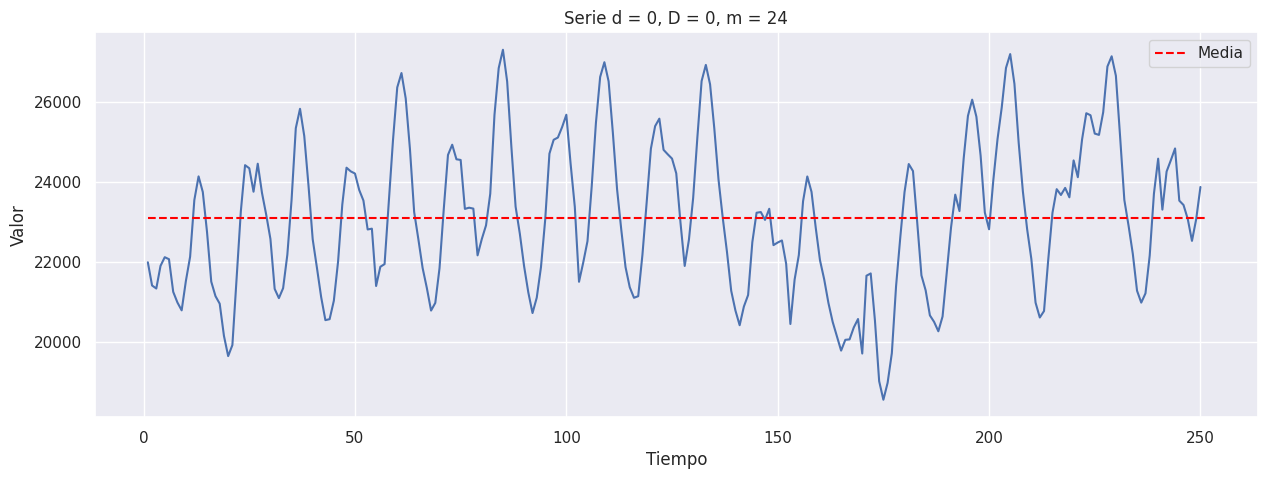

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


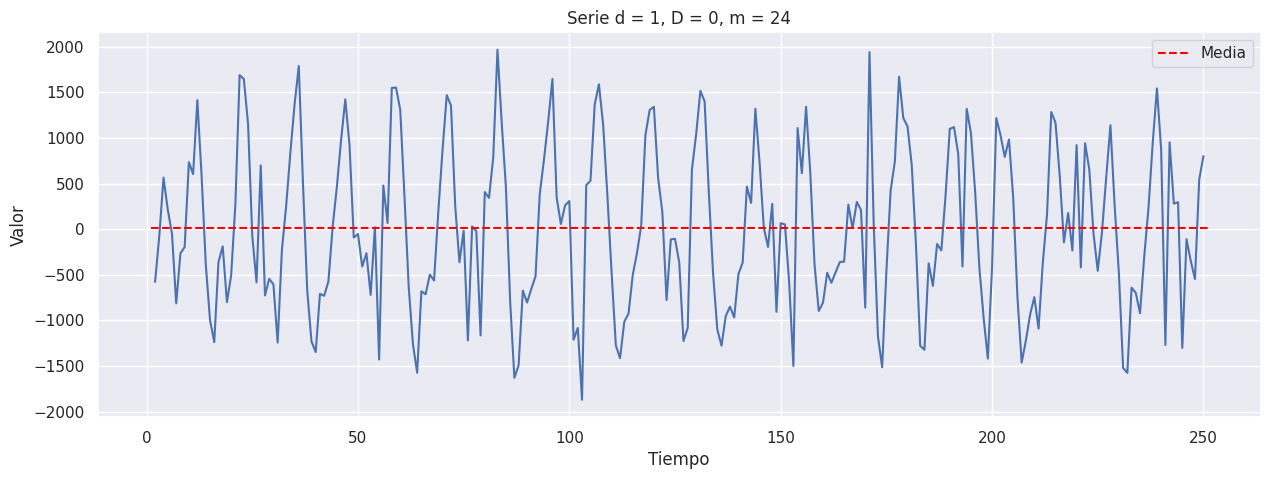

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


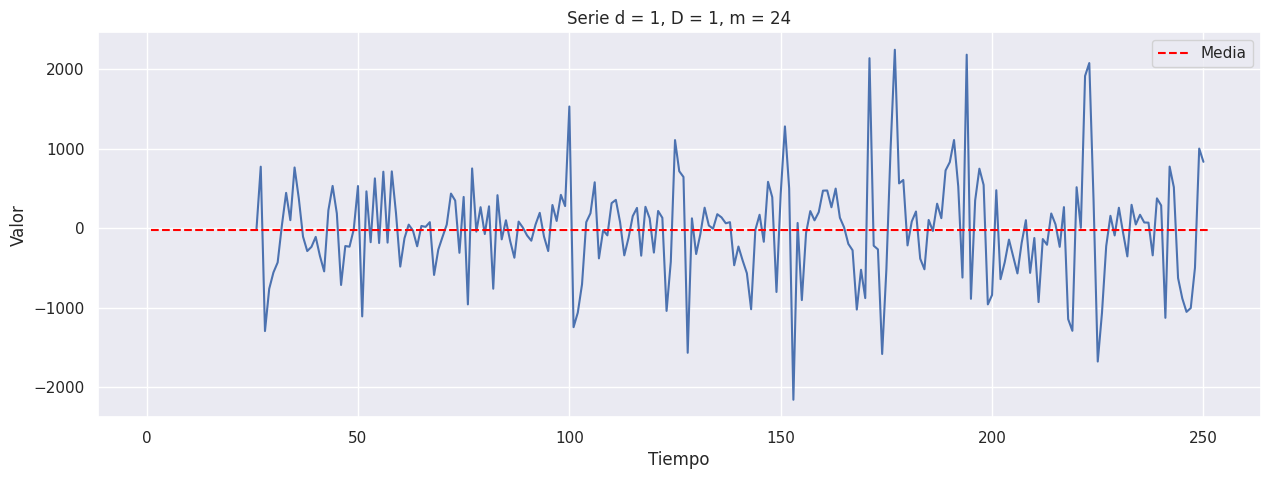

>Prueba Estacionariedad con Dickey-Fuller
Rechazar H0: Serie Estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar más

>Prueba Estacionalidad con Canova‑Hansen
Puede no haber un patrón estacional


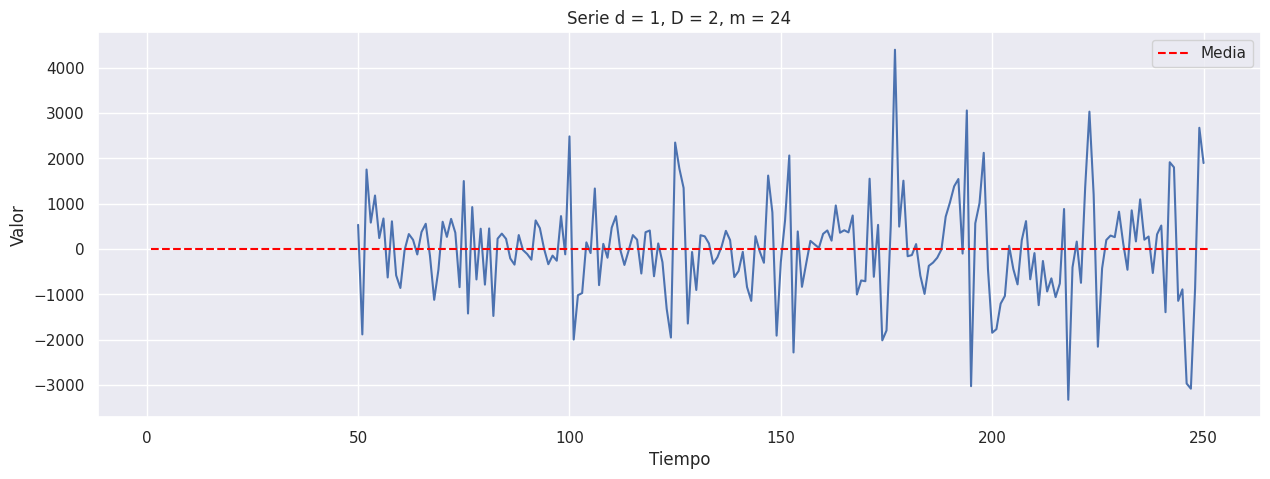

In [53]:
prueba_diferenciacion(df_train['y'][:250], d=0, D=0, m=24)
prueba_diferenciacion(df_train['y'][:250], d=1, D=0, m=24)
prueba_diferenciacion(df_train['y'][:250], d=1, D=1, m=24)
prueba_diferenciacion(df_train['y'][:250], d=1, D=2, m=24)